# 03 — Custom CNN Eğitimi
Stephen et al. 2019 benzeri sıfırdan CNN — Minimal ve CLAHE önişleme ile.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

from models import build_custom_cnn
from preprocessing import make_generator_minimal, make_generator_clahe
from evaluate import evaluate_model, append_metrics_csv, plot_training_history

DATA_DIR    = Path('../data/chest_xray/chest_xray')
RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
METRICS_CSV = str(RESULTS_DIR / 'metrics.csv')

os.makedirs(str(FIGURES_DIR), exist_ok=True)

TRAIN_DIR = str(DATA_DIR / 'train')
VAL_DIR   = str(DATA_DIR / 'val')
TEST_DIR  = str(DATA_DIR / 'test')

BATCH_SIZE = 32
EPOCHS     = 20

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


## Deney A — Minimal Önişleme

In [2]:
train_gen = make_generator_minimal(TRAIN_DIR, augment=True,  batch_size=BATCH_SIZE)
val_gen   = make_generator_minimal(VAL_DIR,   augment=False, batch_size=BATCH_SIZE, shuffle=False)

model_a = build_custom_cnn()
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model_a.summary()

Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 56, 56, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,087,297 (49.92 MB)

 Trainable params: 13,087,105 (49.92 MB)

 Non-trainable params: 192 (768.00 B)

In [3]:
callbacks_a = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../results/custom_cnn_minimal_best.keras',
                                       monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
]

history_a = model_a.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_a,
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 773ms/step - accuracy: 0.8062 - loss: 0.7631 - val_accuracy: 0.7361 - val_loss: 0.5633 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 730ms/step - accuracy: 0.8821 - loss: 0.2868 - val_accuracy: 0.7435 - val_loss: 0.6352 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 695ms/step - accuracy: 0.8926 - loss: 0.2665 - val_accuracy: 0.7881 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 586ms/step - accuracy: 0.9078 - loss: 0.2382 - val_accuracy: 0.9387 - val_loss: 0.2016 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.9082 - loss: 0.2358 - val_accuracy: 0.9275 - val_loss: 0.1947 - learning_rate: 0.0010
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 588ms/step - accuracy: 0.9036 - loss: 0.2441 - val_accuracy: 0.9238 - val_loss: 0.2563 - learning_rate: 0.0010
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 581ms/step - accuracy: 

In [4]:
test_gen_a = make_generator_minimal(TEST_DIR, augment=False, batch_size=BATCH_SIZE, shuffle=False)
metrics_a  = evaluate_model(model_a, test_gen_a, 'custom_cnn', 'minimal')
append_metrics_csv(metrics_a, METRICS_CSV)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step

[custom_cnn | minimal]
  model: custom_cnn
  preprocessing: minimal
  accuracy: 0.8814
  precision: 0.8641
  recall: 0.9615
  f1: 0.9102
  auc: 0.9177
  Confusion matrix kaydedildi: C:\Users\pc\DeepLearning\4.proje\notebooks\..\results\figures\cm_custom_cnn_minimal.png
  ROC eğrisi kaydedildi: C:\Users\pc\DeepLearning\4.proje\notebooks\..\results\figures\roc_custom_cnn_minimal.png


## Deney B — CLAHE Önişleme

In [5]:
train_gen_b = make_generator_clahe(TRAIN_DIR, augment=True,  batch_size=BATCH_SIZE)
val_gen_b   = make_generator_clahe(VAL_DIR,   augment=False, batch_size=BATCH_SIZE, shuffle=False)

model_b = build_custom_cnn()
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

callbacks_b = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../results/custom_cnn_clahe_best.keras',
                                       monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
]

history_b = model_b.fit(
    train_gen_b,
    validation_data=val_gen_b,
    epochs=EPOCHS,
    callbacks=callbacks_b,
)

Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 633ms/step - accuracy: 0.8464 - loss: 0.6534 - val_accuracy: 0.7361 - val_loss: 0.5817 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 641ms/step - accuracy: 0.9001 - loss: 0.2396 - val_accuracy: 0.7361 - val_loss: 0.7856 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 630ms/step - accuracy: 0.9168 - loss: 0.2135 - val_accuracy: 0.9275 - val_loss: 0.2159 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 630ms/step - accuracy: 0.9222 - loss: 0.1939 - val_accuracy: 0.9331 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9281 - loss: 0.1811 - val_accuracy: 0.9312 - val_loss: 0.1531 - learning_rate: 0.0010
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9296 - loss: 0.1834 - val_accuracy: 0.9554 - val_loss: 0.1235 - lea

In [6]:
test_gen_b = make_generator_clahe(TEST_DIR, augment=False, batch_size=BATCH_SIZE, shuffle=False)
metrics_b  = evaluate_model(model_b, test_gen_b, 'custom_cnn', 'clahe')
append_metrics_csv(metrics_b, METRICS_CSV)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step

[custom_cnn | clahe]
  model: custom_cnn
  preprocessing: clahe
  accuracy: 0.8317
  precision: 0.795
  recall: 0.9846
  f1: 0.8797
  auc: 0.9202
  Confusion matrix kaydedildi: C:\Users\pc\DeepLearning\4.proje\notebooks\..\results\figures\cm_custom_cnn_clahe.png
  ROC eğrisi kaydedildi: C:\Users\pc\DeepLearning\4.proje\notebooks\..\results\figures\roc_custom_cnn_clahe.png


## Loss Eğrisi Karşılaştırması

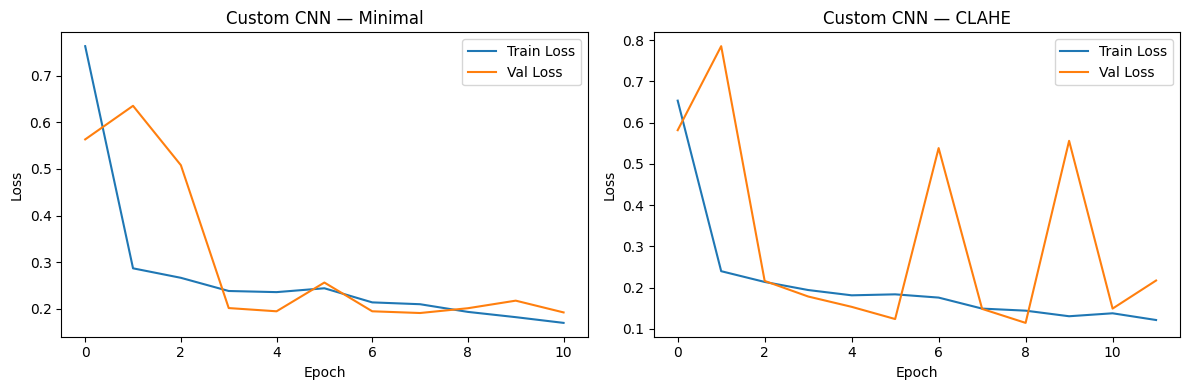

Sonuç metrikleri:
Minimal: {'model': 'custom_cnn', 'preprocessing': 'minimal', 'accuracy': 0.8814, 'precision': 0.8641, 'recall': 0.9615, 'f1': 0.9102, 'auc': 0.9177}
CLAHE:   {'model': 'custom_cnn', 'preprocessing': 'clahe', 'accuracy': 0.8317, 'precision': 0.795, 'recall': 0.9846, 'f1': 0.8797, 'auc': 0.9202}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (hist, label) in zip(axes, [(history_a, 'Minimal'), (history_b, 'CLAHE')]):
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'Custom CNN — {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/custom_cnn_loss_curves.png', dpi=150)
plt.show()
print('Sonuç metrikleri:')
print('Minimal:', metrics_a)
print('CLAHE:  ', metrics_b)